In [1]:
import pandas as pd
import numpy as np
import os 
from pathlib import Path

%matplotlib inline

import matplotlib.pyplot as plt

import seaborn as sn

In [2]:
# Get csvs of results for each model 

def get_df_from_dir(model_paths, talker=False):
    csv_str = 'metrics.csv'
    #models = [attn_models[0], ctrl_models[0]]
    bad_files = []
    dfs = []
    for model in model_paths:
        # get test csvs
        results_csvs = model.rglob("*.csv")

        for csv in results_csvs:
    #         print(csv)
            try:
                df = pd.read_csv(csv)
                #print(model)

                df['version'] = csv.as_posix().split(model.stem)[-1].split('/')[1].split('_')[-1]
                test_parts = str(model).split("/")[-1].split("_")
                #print(test_parts)
                if talker:
                    df['model'] = test_parts[2]
                    df['snr_condition'] = test_parts[3]
                    df['n_talkers'] = test_parts[0]
                else:
                    df['model'] = test_parts[0]
            #       print(test_parts)
                    df['snr_condition'] = test_parts[1]

                if len(df.filter(regex='acc_step').columns) != 0:
                    df["ACC/test_fg_acc"] = df["ACC/test_fg_acc_step"]
                    df["ACC/test_bg_acc"] = df["ACC/test_bg_acc_step"]

                dfs.append(df)
            except Exception as e:
                print(e)
                bad_files.append((csv.as_posix(), e))

    #         if 'Test' in path.as_posix()
    results = pd.concat(dfs, axis=0, ignore_index=True)

    # results.drop('ACC/test_fg_acc_epoch', axis=1, inplace=True)
    # results.drop('ACC/test_bg_acc_epoch', axis=1, inplace=True)
    # results.drop('epoch', axis=1, inplace=True)
    if talker:
        version_maxes = results.groupby(['model', 'snr_condition', 'n_talkers']).version.transform(max)
    else:
        version_maxes = results.groupby(['model', 'snr_condition']).version.transform(max)
    results = results[results.version == version_maxes]
    return results, bad_files 

In [3]:
speaker_f0 = list(Path('/om2/user/imgriff/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_f0_test/').glob("*"))
# audioset_snr = list(Path('/om2/user/imgriff/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_f0_test/').glob("*"))


In [4]:
aud_f0,  _ = get_df_from_dir(speaker_f0)


No columns to parse from file
No columns to parse from file


In [5]:
aud_f0.head()

,ACC/test_fg_acc_eg_0,test_confusion_eg_0,fg_f0_eg_0,bg_f0_eg_0,ACC/test_fg_acc_eg_1,test_confusion_eg_1,fg_f0_eg_1,bg_f0_eg_1,ACC/test_fg_acc_eg_2,test_confusion_eg_2,...,fg_f0_eg_30,bg_f0_eg_30,ACC/test_fg_acc_eg_31,test_confusion_eg_31,fg_f0_eg_31,bg_f0_eg_31,step,version,model,snr_condition
0,1.0,0.0,102.353081,284.020051,1.0,0.0,134.316029,235.900068,1.0,0.0,...,140.336733,147.803872,0.0,0.0,113.270482,109.314875,0.0,0,AttnCNNConstrained,-10dB
1,0.0,0.0,125.064055,111.465163,1.0,0.0,108.241245,116.106526,1.0,0.0,...,157.472016,104.467697,1.0,0.0,194.224351,116.903185,1.0,0,AttnCNNConstrained,-10dB
2,1.0,0.0,161.014615,110.630374,0.0,0.0,143.806599,96.466927,1.0,0.0,...,162.557434,217.166734,1.0,0.0,120.016973,294.394089,2.0,0,AttnCNNConstrained,-10dB
3,0.0,0.0,115.623263,101.125711,0.0,0.0,220.311613,205.257437,1.0,0.0,...,221.756420,NaN,1.0,0.0,190.481851,115.295680,3.0,0,AttnCNNConstrained,-10dB
4,0.0,0.0,96.102733,202.700528,1.0,0.0,215.575422,142.397900,1.0,0.0,...,112.635789,92.988631,1.0,0.0,144.297227,214.834166,4.0,0,AttnCNNConstrained,-10dB


In [ ]:

fg_f0 = list(aud_f0.filter(regex="fg_f0"))
bg_f0 = list(aud_f0.filter(regex="bg_f0"))
acc = list(aud_f0.filter(regex="test_fg_acc"))
confusion = list(aud_f0.filter(regex="test_confusion"))


# semitone_interval = list(coarse_model_results.filter(regex="semi_interval"))


fg_melt = pd.melt(aud_f0, id_vars=['model', 'step', 'snr_condition'],
                            value_vars=fg_f0,
                            var_name='samp_in_batch',
                            value_name='fg_f0')


bg_melt = pd.melt(aud_f0, id_vars=['model', 'step', 'snr_condition'],
                            value_vars=bg_f0,
                            var_name='samp_in_batch',
                            value_name='bg_f0')

acc_melt = pd.melt(aud_f0, id_vars=['model', 'step', 'snr_condition'],
                            value_vars=acc,
                            var_name='samp_in_batch',
                            value_name='acc')


conf_melt = pd.melt(aud_f0, id_vars=['model', 'step', 'snr_condition'],
                            value_vars=confusion,
                            var_name='samp_in_batch',
                            value_name='confusion')


In [8]:
fg_melt

,model,step,snr_condition,samp_in_batch,fg_f0
0,AttnCNNConstrained,0.0,-10dB,fg_f0_eg_0,102.353081
1,AttnCNNConstrained,1.0,-10dB,fg_f0_eg_0,125.064055
2,AttnCNNConstrained,2.0,-10dB,fg_f0_eg_0,161.014615
3,AttnCNNConstrained,3.0,-10dB,fg_f0_eg_0,115.623263
4,AttnCNNConstrained,4.0,-10dB,fg_f0_eg_0,96.102733
...,...,...,...,...,...
4608731,AudiosetBackground,9941.0,clean,fg_f0_eg_31,90.730670
4608732,AudiosetBackground,9942.0,clean,fg_f0_eg_31,117.656224
4608733,AudiosetBackground,9943.0,clean,fg_f0_eg_31,150.539201
4608734,AudiosetBackground,9944.0,clean,fg_f0_eg_31,105.971845


In [18]:
all_results = pd.concat([fg_melt, bg_melt, acc_melt, conf_melt],
          axis=1)

results_to_plot = all_results.loc[:,~all_results.columns.duplicated()].copy()


In [19]:
# Remove nans from bad f0 calc
results_to_plot = results_to_plot[~results_to_plot.fg_f0.isna()]
results_to_plot = results_to_plot[~results_to_plot.bg_f0.isna()]

In [23]:
aud_f0

,ACC/test_fg_acc_eg_0,test_confusion_eg_0,fg_f0_eg_0,bg_f0_eg_0,ACC/test_fg_acc_eg_1,test_confusion_eg_1,fg_f0_eg_1,bg_f0_eg_1,ACC/test_fg_acc_eg_2,test_confusion_eg_2,...,fg_f0_eg_30,bg_f0_eg_30,ACC/test_fg_acc_eg_31,test_confusion_eg_31,fg_f0_eg_31,bg_f0_eg_31,step,version,model,snr_condition
0,1.0,0.0,102.353081,284.020051,1.0,0.0,134.316029,235.900068,1.0,0.0,...,140.336733,147.803872,0.0,0.0,113.270482,109.314875,0.0,0,AttnCNNConstrained,-10dB
1,0.0,0.0,125.064055,111.465163,1.0,0.0,108.241245,116.106526,1.0,0.0,...,157.472016,104.467697,1.0,0.0,194.224351,116.903185,1.0,0,AttnCNNConstrained,-10dB
2,1.0,0.0,161.014615,110.630374,0.0,0.0,143.806599,96.466927,1.0,0.0,...,162.557434,217.166734,1.0,0.0,120.016973,294.394089,2.0,0,AttnCNNConstrained,-10dB
3,0.0,0.0,115.623263,101.125711,0.0,0.0,220.311613,205.257437,1.0,0.0,...,221.756420,NaN,1.0,0.0,190.481851,115.295680,3.0,0,AttnCNNConstrained,-10dB
4,0.0,0.0,96.102733,202.700528,1.0,0.0,215.575422,142.397900,1.0,0.0,...,112.635789,92.988631,1.0,0.0,144.297227,214.834166,4.0,0,AttnCNNConstrained,-10dB
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183030,1.0,0.0,119.061402,222.589861,0.0,0.0,158.586705,NaN,1.0,0.0,...,81.777558,182.684625,1.0,0.0,90.730670,NaN,9941.0,3,AudiosetBackground,clean
183031,1.0,0.0,120.355869,NaN,1.0,0.0,200.050260,169.548340,1.0,0.0,...,137.744718,179.272921,1.0,0.0,117.656224,136.021130,9942.0,3,AudiosetBackground,clean
183032,1.0,0.0,117.489180,158.379977,1.0,0.0,184.482998,139.430079,1.0,0.0,...,204.503520,102.413322,1.0,0.0,150.539201,117.657037,9943.0,3,AudiosetBackground,clean
183033,1.0,0.0,203.131554,125.409546,0.0,0.0,163.200534,98.625717,1.0,0.0,...,113.343399,100.500014,0.0,0.0,105.971845,138.115057,9944.0,3,AudiosetBackground,clean


In [22]:
results_to_plot

,model,step,snr_condition,samp_in_batch,fg_f0,bg_f0,acc,confusion
0,AttnCNNConstrained,0.0,-10dB,fg_f0_eg_0,102.353081,284.020051,1.0,0.0
1,AttnCNNConstrained,1.0,-10dB,fg_f0_eg_0,125.064055,111.465163,0.0,0.0
2,AttnCNNConstrained,2.0,-10dB,fg_f0_eg_0,161.014615,110.630374,1.0,0.0
3,AttnCNNConstrained,3.0,-10dB,fg_f0_eg_0,115.623263,101.125711,0.0,0.0
4,AttnCNNConstrained,4.0,-10dB,fg_f0_eg_0,96.102733,202.700528,0.0,0.0
...,...,...,...,...,...,...,...,...
4608730,AudiosetBackground,9940.0,clean,fg_f0_eg_31,100.587939,123.652738,1.0,0.0
4608732,AudiosetBackground,9942.0,clean,fg_f0_eg_31,117.656224,136.021130,1.0,0.0
4608733,AudiosetBackground,9943.0,clean,fg_f0_eg_31,150.539201,117.657037,1.0,0.0
4608734,AudiosetBackground,9944.0,clean,fg_f0_eg_31,105.971845,138.115057,0.0,0.0


In [24]:
results_to_plot['f0_diff'] = (results_to_plot['fg_f0'] - results_to_plot['bg_f0']).abs()

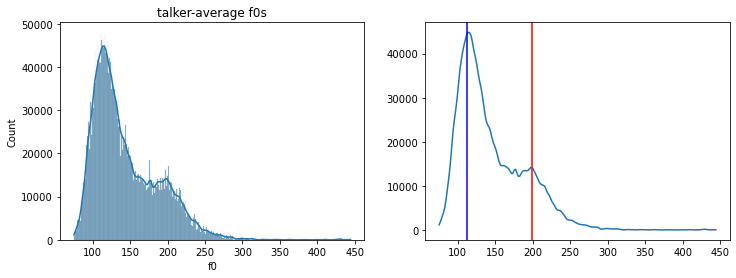

In [25]:
## Get histogram of foreground f0s 

fig, [ax1, ax2] = plt.subplots(1,2, figsize=(12,4))

g = sn.histplot(data=results_to_plot, x='fg_f0', kde=True, ax=ax1)
g.set_xlabel('f0')
g.set_title('talker-average f0s')

# Peaks are M/F centers. Get centers F0 for male & female talkers
lines = g.get_lines()[0] # get kde trace 
f0s = lines.get_xdata()
kde_trace = lines.get_ydata()

from scipy.signal import find_peaks, find_peaks_cwt
# use wavelet to find means in data for male & female voices - 10 to 50 frame window gives same result
male_m, female_m = f0s[find_peaks_cwt(kde_trace, np.arange(1,10))][:2].round(2)

ax2.plot(f0s, kde_trace)
ax2.axvline(male_m, ymin=0, color='b')
ax2.axvline(female_m, ymin=0, color='r')


In [26]:
## Update df with male-female labels
def sex_pairing(fg_f0, bg_f0, male_mean=male_m, female_mean=female_m):
    """Return target-deistractor sex pairing"""
    is_female = lambda x: abs(x - male_m) > abs(x - female_m)
    fg_sex = 'female' if is_female(fg_f0) else 'male'
    bg_sex = 'female' if is_female(bg_f0) else 'male'
    # return pairing
    return f"{fg_sex}/{bg_sex}"




results_to_plot['sex_pairing'] = results_to_plot[['fg_f0', 'bg_f0']].apply(lambda x: sex_pairing(*x), axis=1)

In [95]:
# same/diff sex

results_to_plot['coarse_sex_pairing'] = results_to_plot['sex_pairing'].str.contains('female/female|male/male')
results_to_plot['coarse_sex_pairing'][results_to_plot['coarse_sex_pairing'] == True] = 'same'
results_to_plot['coarse_sex_pairing'][results_to_plot['coarse_sex_pairing'] == False] = 'different'

/tmp/ipykernel_29918/3043500636.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results_to_plot['coarse_sex_pairing'][results_to_plot['coarse_sex_pairing'] == True] = 'same'


In [36]:
# get f0 diff in semitones 
# semitones = 12 * np.log2(f2 / f1) for f2,f1 in Hz

results_to_plot['semitone_diff'] = 12 * np.log2(results_to_plot['bg_f0'] / results_to_plot['fg_f0'])

results_to_plot['abs_semitone_diff'] = results_to_plot['semitone_diff'].abs()

Text(0.5, 1.0, 'distribution of target-distractor pairings')

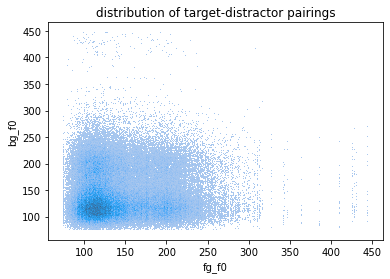

In [29]:
# Plot dist of f0 pairings 
g = sn.histplot(data=results_to_plot, x='fg_f0', y='bg_f0')
# g.set_xlabel('f0')
g.set_title('distribution of target-distractor pairings')

Text(0.5, 1.0, 'difference in target-distractor f0')

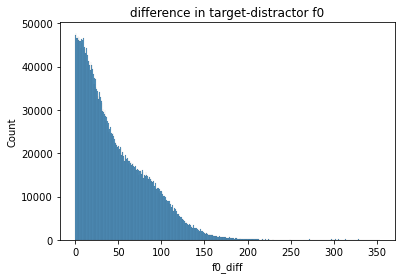

In [30]:
# Plot dist of f0 differences 
g = sn.histplot(data=results_to_plot, x='f0_diff')
g.set_title('difference in target-distractor f0')

Text(0.5, 1.0, 'f0 difference in semitones')

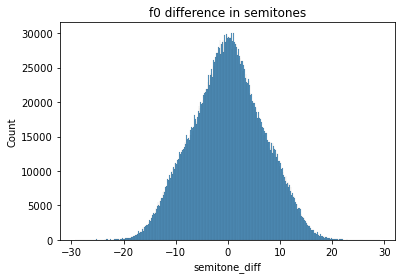

In [35]:
# Plot dist of f0 differences 
g = sn.histplot(data=results_to_plot, x='semitone_diff')
g.set_title('f0 difference in semitones')

Text(0.5, 1.0, 'absolute f0 difference in semitones')

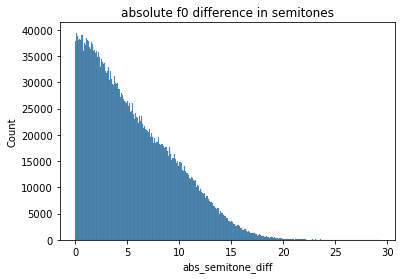

In [101]:
# Plot dist of f0 differences 
g = sn.histplot(data=results_to_plot, x='abs_semitone_diff')
g.set_title('absolute f0 difference in semitones')

In [70]:
## Bin f0 diffs for plotting 

f0s = np.array([0, 1, 2, 3, 4, 6, 9, 12])

class_ixs =  np.abs(results_to_plot['abs_semitone_diff'].to_numpy() - f0s.reshape(-1,1)).argmin(0)
results_to_plot['f0_diff_class'] = [f0s[ix] for ix in class_ixs]


In [65]:
results_to_plot

,model,step,snr_condition,samp_in_batch,fg_f0,bg_f0,acc,confusion,f0_diff,sex_pairing,semitone_diff,abs_semitone_diff,f0_diff_class
0,single talker,0.0,-10dB,fg_f0_eg_0,102.353081,284.020051,1.0,0.0,181.666970,male/female,17.669259,17.669259,0
1,single talker,1.0,-10dB,fg_f0_eg_0,125.064055,111.465163,0.0,0.0,13.598892,male/male,-1.992892,1.992892,7
2,single talker,2.0,-10dB,fg_f0_eg_0,161.014615,110.630374,1.0,0.0,50.384241,female/male,-6.497329,6.497329,0
3,single talker,3.0,-10dB,fg_f0_eg_0,115.623263,101.125711,0.0,0.0,14.497552,male/male,-2.319382,2.319382,7
4,single talker,4.0,-10dB,fg_f0_eg_0,96.102733,202.700528,0.0,0.0,106.597795,male/female,12.920406,12.920406,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4608730,audioset,9940.0,clean,fg_f0_eg_31,100.587939,123.652738,1.0,0.0,23.064799,male/male,3.574042,3.574042,7
4608732,audioset,9942.0,clean,fg_f0_eg_31,117.656224,136.021130,1.0,0.0,18.364905,male/male,2.511038,2.511038,7
4608733,audioset,9943.0,clean,fg_f0_eg_31,150.539201,117.657037,1.0,0.0,32.882164,male/male,-4.266619,4.266619,7
4608734,audioset,9944.0,clean,fg_f0_eg_31,105.971845,138.115057,0.0,0.0,32.143212,male/male,4.586275,4.586275,7


In [31]:
# Update model names for plot

results_to_plot['model'].replace('AttnCNNConstrained','single talker',inplace=True)
results_to_plot['model'].replace('AudiosetBackground','audioset',inplace=True)



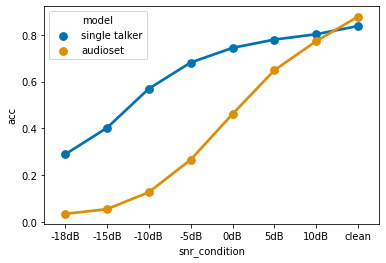

In [32]:
# fig, axs = plt.subplots(1,1, sharey=True, figsize=(15,5))
# axs = axs.ravel()



snr_order = ['-18dB', '-15dB', '-10dB', '-5dB', '0dB', '5dB', '10dB', 'clean']

g = sn.pointplot(
    data=results_to_plot, x='snr_condition', y='acc',
    hue='model', #hue_order=hue_order,
#     ci=95, seed=1, ax=axs,
    palette='colorblind', order=snr_order
)


In [98]:
# Make labels for same/diff pairs

sd_hue_tags = results_to_plot['model'] + ' ' + results_to_plot['coarse_sex_pairing']
# get order of model-sd conditions 
sd_hue_order = np.sort(sd_hue_tags.unique())
# put in order for diverging color map: cue 1-2, control 2-1
sd_hue_order = np.hstack([sd_hue_order[2:], sd_hue_order[:2][::-1]])
# set color map and get color dict
sd_cmap = sn.color_palette("coolwarm", len(sd_hue_order), as_cmap=False)
sd_palette = {cond:sd_cmap[ix] for ix, cond in enumerate(sd_hue_order)}
# get wanted order: cue 1-2 control 1-2
sd_hue_order = np.hstack([sd_hue_order[:2], sd_hue_order[2:][::-1]])




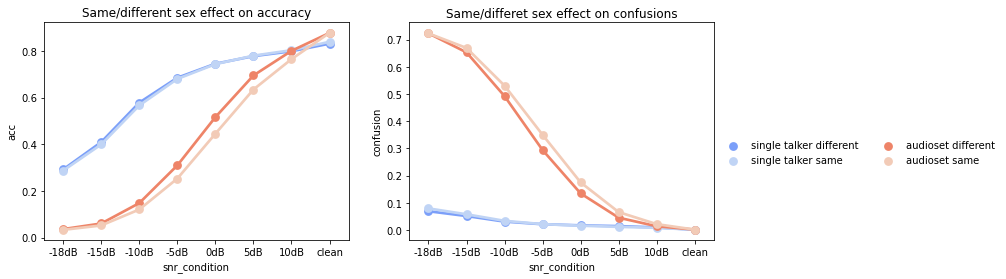

In [100]:
# Plot distractor sex pairs 
fig, [ax1, ax2] = plt.subplots(1,2, figsize=(12,4))



sd = sn.pointplot(
    data=results_to_plot, x='snr_condition', y='acc',
#     col='n_sds', col_wrap=2,
    hue=sd_hue_tags,
    hue_order=sd_hue_order,
#     ci=95, seed=1,
    palette=sd_palette, order=snr_order,
     ax=ax1
)
sd.legend_.remove()
sd.set_title("Same/different sex effect on accuracy")

sd2 = sn.pointplot(
    data=results_to_plot, x='snr_condition', y='confusion',
#     col='n_sds', col_wrap=2,
    hue=sd_hue_tags,
    hue_order=sd_hue_order,
#     ci=95, seed=1,
    palette=sd_palette, order=snr_order,
     ax=ax2
)
sd2.set_title("Same/differet sex effect on confusions")

sd2.legend(title='', ncol=2, bbox_to_anchor=(1, 0.5), frameon=False)



In [97]:
# Make labels for m/f pairs

mf_hue_tags = results_to_plot['model'] + ' ' + results_to_plot['sex_pairing']
# get order of model-mf conditions 
mf_hue_order = np.sort(mf_hue_tags.unique())
# put in order for diverging color map: cue 1-4, control 4-1
mf_hue_order = np.hstack([mf_hue_order[4:], mf_hue_order[:4][::-1]])
# set color map and get color dict
mf_cmap = sn.color_palette("coolwarm", len(mf_hue_order), as_cmap=False)
mf_palette = {cond:mf_cmap[ix] for ix, cond in enumerate(mf_hue_order)}
# get wanted order: cue 1-4 control 1-4
mf_hue_order = np.hstack([mf_hue_order[:4], mf_hue_order[4:][::-1]])




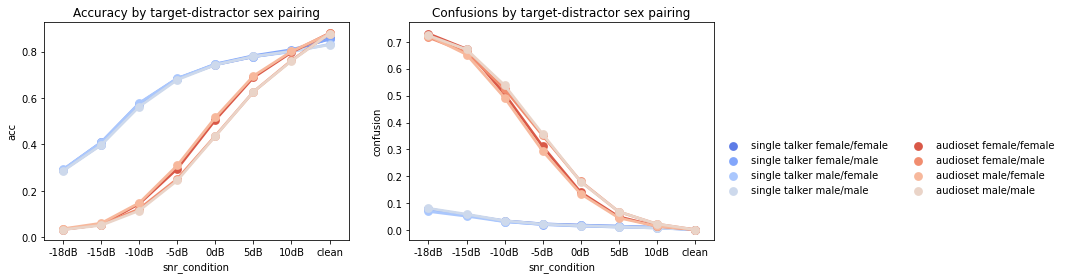

In [91]:
# Plot distractor sex pairs 
fig, [ax1, ax2] = plt.subplots(1,2, figsize=(12,4))

mf = sn.pointplot(
    data=results_to_plot, x='snr_condition', y='acc',
#     col='n_mfs', col_wrap=2,
    hue=mf_hue_tags,
    hue_order=mf_hue_order,
#     ci=95, seed=1,
    palette=mf_palette, order=snr_order,
     ax=ax1
)
mf.legend_.remove()
mf.set_title("Accuracy by target-distractor sex pairing")

mf2 = sn.pointplot(
    data=results_to_plot, x='snr_condition', y='confusion',
#     col='n_mfs', col_wrap=2,
    hue=mf_hue_tags,
    hue_order=mf_hue_order,
#     ci=95, seed=1,
    palette=mf_palette, order=snr_order,
     ax=ax2
)
mf2.set_title("Confusions by target-distractor sex pairing")

mf2.legend(title='', ncol=2, bbox_to_anchor=(1, 0.5), frameon=False)



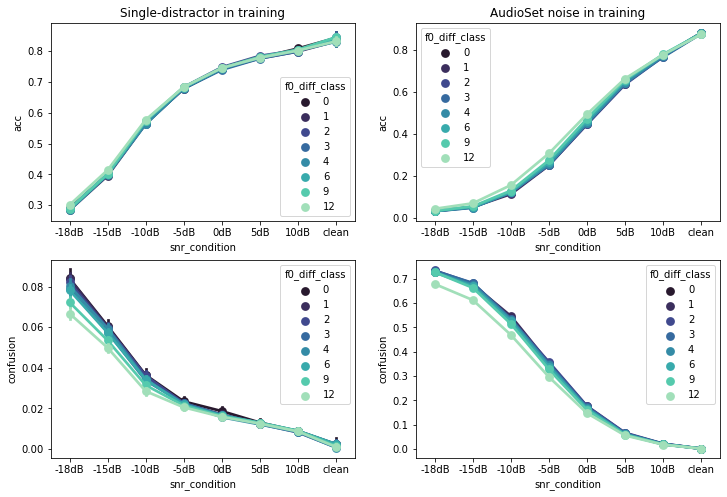

In [89]:
# Plot performance across f0 
# 
fig, axs = plt.subplots(2,2, figsize=(12,8))
ax1, ax2, ax3, ax4 = axs.ravel()

f0_order = [0, 1, 2, 3, 4, 6, 9, 12]

g = sn.pointplot(
    data=results_to_plot[results_to_plot.model == 'single talker'],
    x='snr_condition', y='acc',
    hue='f0_diff_class', hue_order=f0_order,
    ax=ax1, order=snr_order,
#     ci=95, seed=1, 
    palette='mako', 
)

g.set_title("Single-distractor in training")

g2 = sn.pointplot(
    data=results_to_plot[results_to_plot.model == 'audioset'],
    x='snr_condition', y='acc',
    hue='f0_diff_class', hue_order=f0_order,
    ax=ax2, order=snr_order,
#     ci=95, seed=1, 
    palette='mako', 
)

g2.set_title("AudioSet noise in training")

g3 = sn.pointplot(
    data=results_to_plot[results_to_plot.model == 'single talker'],
    x='snr_condition', y='confusion',
    hue='f0_diff_class', hue_order=f0_order,
    ax=ax3, order=snr_order,
#     ci=95, seed=1, 
    palette='mako', 
)


g4 = sn.pointplot(
    data=results_to_plot[results_to_plot.model == 'audioset'],
    x='snr_condition', y='confusion',
    hue='f0_diff_class', hue_order=f0_order,
    ax=ax4, order=snr_order,
#     ci=95, seed=1, 
    palette='mako', 
)




In [75]:
results_to_plot.model.unique()

array(['single talker', 'audioset'], dtype=object)